# Семинар №4

## <center>Convolutional neural network`</center>

### <center> Small reminder </center>

> **What is it?**
>    * a type of artificial neural network where the architecture is such that the incoming data is identified as image and processed with a kernel of specific size
>    * it can be either **`Conv1d`** - for vectors of size (batch, channels, length); **`Conv2d`** - for images of size (batch, channels, height, width) and **`Conv3d`**.

![image](conv2d_padding.gif)

>    * all of the modules have the following params:
>     * **`in_channels`** - № of imput channels (3 for RGB, 1 for grayscale)
>     * **`out_channels`** - № of output channels, produced by the layer
>     * **`kernel_size`** - size of the kernel, processing the image
>     * **`stride`** - convolution's kernel step between scannings
>     * **`padding`** - size of the padding, number of zeros to extend the image
>     * **`dilation`** - step between kernel's elements within itself
>     * **`bias`** - boolean flag either to add learnable bias or not

### <center> Basic Training </center>

**1. Libraries**

In [1]:
# ===== ИМПОРТ НЕОБХОДИМЫХ БИБЛИОТЕК =====

# Основные библиотеки Python для работы с данными
import os  # Модуль для работы с операционной системой: пути к файлам, обход каталогов и т.д.
import numpy as np  # NumPy - фундаментальная библиотека для работы с многомерными массивами и математическими операциями
import pandas as pd  # Pandas - библиотека для работы с табличными данными (в этом ноутбуке не используется активно)
import matplotlib.pyplot as plt  # Matplotlib - главная библиотека для визуализации данных: графики, изображения и пр.

# Базовые компоненты PyTorch
import torch  # Основная библиотека PyTorch для работы с тензорами (многомерными массивами на GPU/CPU)
from torch import nn  # nn (neural networks) - модуль с классами для построения нейронных сетей (слои, функции активации)

# Работа с датасетами в PyTorch
from torch.utils.data import Dataset  # Базовый класс для создания собственных датасетов

# Torchvision - библиотека с готовыми датасетами и трансформациями для компьютерного зрения
from torchvision import datasets, transforms  # datasets - готовые датасеты (MNIST, CIFAR и др.), transforms - преобразования изображений
from torchvision.transforms import ToTensor  # ToTensor - преобразует изображение (PIL или numpy) в тензор PyTorch
from torchvision.io import read_image  # Функция для чтения изображения с диска и преобразования в тензор

# DataLoader для батчевой загрузки данных
from torch.utils.data import DataLoader  # Класс для загрузки данных пакетами (батчами), перемешивания, параллельной загрузки

# Дополнительные модули
import torch.nn.functional as F  # Функциональный API PyTorch: функции активации, потери и др. без создания объектов
import cv2  # OpenCV - мощная библиотека для работы с изображениями и видео (чтение, изменение размера, фильтры)

# Утилиты для Jupyter Notebook
from tqdm.notebook import tqdm  # tqdm - прогресс-бар для циклов, версия для Jupyter Notebook
from IPython.display import clear_output  # Функция для очистки вывода ячейки в Jupyter (полезно при визуализации обучения)

**2. Dataset**

In [2]:
# ===== НАСТРОЙКА ПУТЕЙ И ПАРАМЕТРОВ ДАТАСЕТА =====

# Команды для загрузки датасета с Kaggle (закомментированы, так как датасет уже загружен)
#!mv kaggle.json /root/.kaggle/  # Перемещаем файл с ключом API Kaggle в нужную директорию
#!kaggle datasets download -d sartajbhuvaji/brain-tumor-classification-mri  # Загрузка датасета с MRI-сканами мозга для классификации опухолей
#!unzip /content/brain-tumor-classification-mri.zip  # Распаковка архива с данными

# Пути к папкам с данными
train_dir = ('mri/Training/')  # Путь к папке с обучающей выборкой изображений
test_dir = ('mri/Testing/')  # Путь к папке с тестовой выборкой изображений

# Размер изображений для нормализации
img_size = 300  # Все изображения будут приведены к размеру 300x300 пикселей (стандартизация входа сети)

# Словарь для преобразования названий классов в числовые метки
class_map = {
    'no_tumor': 0,            # Класс 0: нет опухоли (здоровый мозг)
    'glioma_tumor': 1,        # Класс 1: глиома (злокачественная опухоль из глиальных клеток)
    'meningioma_tumor': 2,    # Класс 2: менингиома (опухоль мозговых оболочек, часто доброкачественная)
    'pituitary_tumor': 3      # Класс 3: опухоль гипофиза (аденома)
}

In [ ]:
# ===== ЗАГРУЗКА И ПРЕДОБРАБОТКА ИЗОБРАЖЕНИЙ =====

# Инициализация пустых списков для хранения данных
train_img = []      # Список для хранения обучающих изображений (NumPy массивы)
train_labels = []   # Список для хранения меток классов для обучающей выборки

test_img = []       # Список для хранения тестовых изображений
test_labels = []    # Список для хранения меток классов для тестовой выборки

# Обход обучающей выборки: перебираем папки с названиями классов
for i in os.listdir(train_dir):  # i - название папки (класса): 'no_tumor', 'glioma_tumor' и т.д.
    for j in os.listdir(train_dir+i):  # j - имя файла изображения внутри папки класса
        # Читаем изображение, изменяем размер и добавляем в список
        train_img.append(
            cv2.resize(  # cv2.resize - изменение размера изображения до 300x300
                cv2.imread(train_dir+i+'/'+j),  # cv2.imread - чтение изображения с диска в формате NumPy-массива (BGR)
                (img_size, img_size)  # Целевой размер: (300, 300) пикселей
            )
        )
        # Добавляем числовую метку класса, используя словарь class_map
        train_labels.append(class_map[i])  # Преобразуем 'no_tumor' → 0, 'glioma_tumor' → 1 и т.д.

# Аналогичный обход для тестовой выборки
for i in os.listdir(test_dir):  # Перебираем папки с классами в тестовой выборке
    for j in os.listdir(test_dir+i):  # Перебираем файлы внутри каждой папки
        test_img.append(
            cv2.resize(
                cv2.imread(test_dir+i+'/'+j),
                (img_size, img_size)
            )
        )
        test_labels.append(class_map[i])

# Преобразование списков Python в NumPy-массивы
train_img = np.array(train_img)   # Преобразуем в массив с формой (N_train, 300, 300, 3) - N изображений, 3 канала (BGR)
test_img = np.array(test_img)     # Преобразуем в массив с формой (N_test, 300, 300, 3)

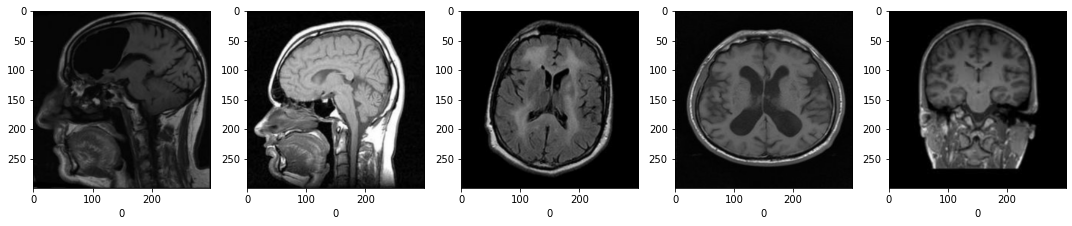

In [ ]:
# ===== ВИЗУАЛИЗАЦИЯ ПРИМЕРОВ ИЗ ДАТАСЕТА =====

# Создаём фигуру для отображения нескольких изображений
plt.figure(figsize=(15,15))  # figsize - размер фигуры в дюймах (ширина, высота)

# Цикл для отображения первых 5 изображений из обучающей выборки
for i, j in enumerate(train_img[:5]):  # enumerate - возвращает индекс (i) и элемент (j), [:5] - первые 5 элементов
    plt.subplot(1, 5, i+1)  # Создаём подграфик: 1 строка, 5 столбцов, позиция (i+1) - нумерация с 1
    plt.imshow(j)  # Отображаем изображение (j - массив NumPy с пикселями)
    plt.xlabel(train_labels[i])  # Добавляем подпись по оси X - номер класса (0, 1, 2 или 3)
    plt.tight_layout()  # Автоматическая подгонка расстояний между подграфиками

In [15]:
type(train_img[0])

numpy.ndarray

In [5]:
# ===== ОПРЕДЕЛЕНИЕ ТРАНСФОРМАЦИЙ И ЗАГРУЗКА ДАТАСЕТОВ =====

# Создаём композицию (последовательность) преобразований, которые будут применяться к каждому изображению
data_transform = transforms.Compose([
    # 1. Изменение размера всех изображений к 300x300 пикселей (стандартизация)
    transforms.Resize((img_size, img_size)),  
    
    # 2. Преобразование изображения в тензор PyTorch
    # Преобразует PIL Image или NumPy (H, W, C) в тензор (C, H, W) с значениями [0, 1]
    transforms.ToTensor(),  
    
    # 3. Нормализация: приводим значения пикселей к диапазону [-1, 1]
    # Формула: normalized = (input - mean) / std
    # Для RGB: mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5] → (x - 0.5) / 0.5 = 2x - 1
    # Это преобразует диапазон [0, 1] в [-1, 1], что улучшает сходимость обучения
    transforms.Normalize([0.5,0.5,0.5], [0.5,0.5,0.5])  
])

# Загрузка обучающей выборки с помощью ImageFolder
# ImageFolder автоматически создаёт датасет из структуры папок: root/class1/, root/class2/, ...
train_data = datasets.ImageFolder(
    root='mri/Training/',  # Корневая папка с подпапками-классами
    transform=data_transform,  # Применяем трансформации к каждому изображению при загрузке
    target_transform=None  # Не применяем трансформации к меткам классов
)

# Загрузка тестовой выборки (аналогично обучающей)
test_data = datasets.ImageFolder(
    root='mri/Testing/',  
    transform=data_transform,  
    target_transform=None
)

**3. Dataloader**

In [6]:
# ===== СОЗДАНИЕ DATALOADER ДЛЯ БАТЧЕВОЙ ЗАГРУЗКИ =====

# DataLoader для обучающей выборки
# DataLoader - итератор, который загружает данные пакетами (батчами) для эффективного обучения
train_loader = DataLoader(
    train_data,              # Датасет для обучения (train_data, созданный ранее)
    batch_size=64,           # Размер батча: сколько изображений обрабатывается за одну итерацию
    shuffle=True             # Перемешивание данных перед каждой эпохой (улучшает обобщение модели)
)

# DataLoader для тестовой выборки
test_loader = DataLoader(
    test_data,               # Датасет для тестирования
    batch_size=64,           # Тот же размер батча для согласованности
    shuffle=False            # НЕ перемешиваем тестовые данные (важен порядок для оценки)
)

**4. Neural network**

height_1 = (height_0 + 2 * padding - dilation * (kernel_size[0] + 1) - 1) / stride + 1

In [7]:
class ConvNet(nn.Module):
    def __init__(self, input_channels=3, num_classes=4):
        super().__init__()
        
        self.conv = nn.Sequential( # класс, где "как в списке" перечислены слои для последовательного запуска
            nn.Conv2d(in_channels=input_channels, out_channels=12, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(num_features=12), # нормализуем, на вход число каналов от последней свертки
            nn.ReLU(), # для нелинейности
            nn.MaxPool2d(kernel_size=2), # уменьшаем картинку, stride=kernel_size
            nn.Conv2d(in_channels=12, out_channels=20, kernel_size=3,stride=1,padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=20,out_channels=32, kernel_size=3,stride=1,padding=1),
            nn.BatchNorm2d(num_features=32),
            nn.ReLU()
        )
        self.fc = nn.Linear(in_features=150 * 150 * 32, out_features=num_classes)

    def forward(self, x):
        # x размерности (64 img, 3 channels, 300, 300)
        # после сверток (self.conv) размерность (64 img, 32 channels, 150, 150)
        # выпрямление (flatten) - (64, 32 * 150 * 150)
        
        x_conv = torch.flatten(self.conv(x), 1)
        return self.fc(x_conv) # вернет 64 картинки, 4 предсказания, по одному на класс

In [8]:
# device - процессор, на котором будем считать
# если на cuda (gpu) то можем считать параллельно
# если cpu, то не можем считать параллельно

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ConvNet(num_classes=4) # проинициализировали модель
model = model.to(device) # "положили" модель на выбранный процессор (device)

In [42]:
print('№ params in cnn:', sum(p.numel() for p in model.parameters() if p.requires_grad))

№ params in cnn: 2888400


**5. Hyperparameters**

In [43]:
from torch.optim.lr_scheduler import ExponentialLR

lr = 0.01 # learning rate, шаг обучения

# optimizer - инструмент, который отвечает за обновление параметров модели 
# согласно своим формулам через метод optimizer.step() . У каждого оптимизатора свои формула
# Например, torch.optim.SGD будет обновлять веса по формуле: w = w - grad_w * lr
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
# AdamW - это метод оптимизации: SGD + momentum + weight_decay (L2-регуляризация)

# scheduler - инструмент для обновления learning_rate по разным стратегиям 
# ExponentialLR будет уменьшать экспоненциально наш шаг обучения каждый следующий батч или эпоху
# для обновления learning_rate будем запускать метод scheduler.step()
scheduler = ExponentialLR(optimizer, gamma=0.9)

# функция потерь, для multi-class классификации обычно используется CrossEntropy
# ее можно найти в torch.nn.functional.cross_entropy или как torch.nn.CrossEntropyLoss
criterion = F.cross_entropy

**6. Training & Inference**

In [32]:
def train_epoch(model, optimizer, criterion, scheduler=None, batchsize=32):
    loss_log, acc_log = [], []
    model.train() # переводим модель в режим обучения
    # у нас есть определенные слои, которые по разному себя ведут на обучении и тестировании (e.g. BatchNorm, Dropout)
    # когда вызываем метод model.train мы показываем модели, что сейчас работаем в режиме обучения
    
    for batch_num, (x_batch, y_batch) in tqdm(enumerate(train_loader), total=len(train_loader)):
        data = x_batch.to(device) # переносим изображения на процессор
        target = y_batch.to(device) # переносим таргеты на процессор

        output = model(data) # запуск модели через метод model.forward(data), получение выходов модели
        pred = torch.argmax(output, -1) # выбираем предсказание для каждого объекта = класс, получивший наиб. значение предсказания
        loss = criterion(output, target.long()) # считаем функцию ошибки cross_entropy
        acc = torch.eq(pred, target).float().mean().cpu() # долю правильно угаданных ответов (accuracy)
        # метод cpu забирает с cuda (если она доступна и тензоры там) посчитанный тензор совпадений, чтобы построить график
        acc_log.append(acc)

        optimizer.zero_grad() # обнуляем градиенты, записанные в параметрах модели (которые мы передали в optimizer)
        loss.backward() # backpropagation, считаем градиенты для ВСЕХ участвовавших тензоров в подсчете loss
        optimizer.step
        () # обновление параметров по правилу конкретного optimizer
        if scheduler is not None: scheduler.step() # если scheduler в доступе, после каждого батча обновляем learning_rate
        loss_log.append(loss.item()) # сохраняем значение ошибки
        
    return loss_log, acc_log

def test(model, criterion):
    loss_log, acc_log = [], []
    model.eval() # переводим модель в режим валидации, аналог метода model.train
    
    for batch_num, (x_batch, y_batch) in enumerate(test_loader):
        data = x_batch.to(device)
        target = y_batch.to(device)

        output = model(data)
        pred = torch.argmax(output, -1)
        loss = criterion(output, target.long()).cpu()

        loss_log.appen
            d(loss.item())
        acc = torch.eq(pred, target).float().mean().cpu()
        acc_log.append(acc)
    return loss_log, acc_log


def plot_history(train_history, val_history, title='loss'):
    fig = plt.figure()
    plt.title('{}'.format(title))
    plt.plot(train_history[::10], label='train', zorder=1)

    points = np.array(val_history)
    plt.scatter(points[:, 0]//10, points[:, 1], marker='+', s=180, c='orange', label='val', zorder=2)
    plt.xlabel('train steps')

    plt.legend(loc='best')
    plt.grid()
    plt.show()

    return fig


def train(model, opt, criterion, n_epochs, scheduler=None, batch_size=32):
    train_log, train_acc_log = [], []
    val_log, val_acc_log = [], []


    for epoch in range(n_epochs):
        print("Epoch {0} of {1}".format(epoch, n_epochs))
        train_loss, train_acc = train_epoch(model, opt, criterion, scheduler=scheduler, batchsize=batch_size)
        val_loss, val_acc = test(model, criterion)

        train_log.extend(train_loss)
        train_acc_log.extend(train_acc)

        steps = train_data.__len__() / batch_size
        val_log.append((steps * (epoch + 1), np.mean(val_loss)))
        val_acc_log.append((steps * (epoch + 1), np.mean(val_acc)))

        clear_output()
        fig = plot_history(train_log, val_log)
        plot_history(train_acc_log, val_acc_log, title='accuracy')

        print("Epoch: {2}, val loss: {0}, val accuracy: {1}".format(np.mean(val_loss), np.mean(val_acc), epoch))
    return fig

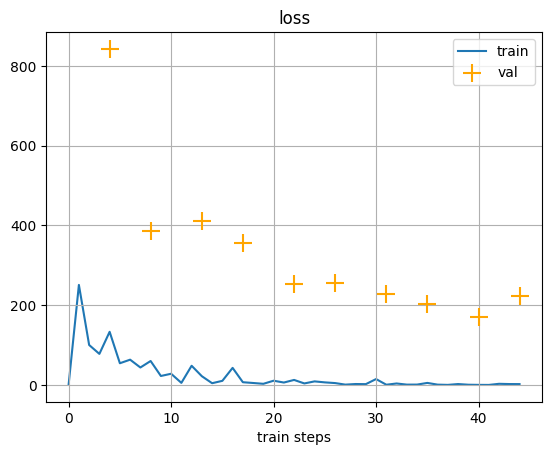

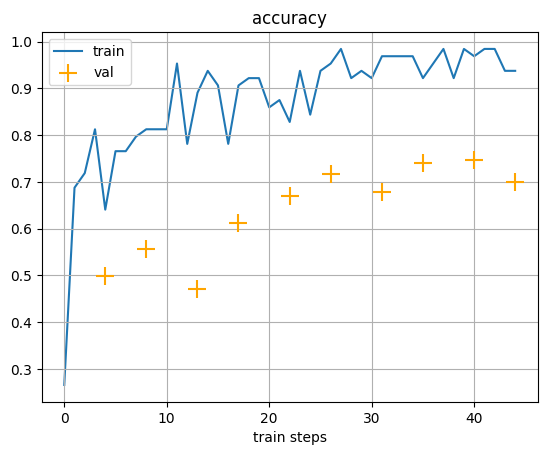

Epoch: 9, val loss: 222.98794037955147, val accuracy: 0.6986607313156128


In [45]:
fig = train(model, optimizer, criterion, n_epochs=10, scheduler=None, batch_size=64)

### <center> Аугментация </center>

In [61]:
# ===== АУГМЕНТАЦИЯ ДАННЫХ: РАСШИРЕННЫЕ ТРАНСФОРМАЦИИ ДЛЯ УВЕЛИЧЕНИЯ ДАТАСЕТА =====

# Создаём композицию трансформаций С АУГМЕНТАЦИЕЙ для обучающей выборки
# Аугментация - искусственное увеличение размера датасета путём случайных преобразований изображений
data_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),  # Изменяем размер до 300x300 пикселей
    transforms.ToTensor(),  # Преобразуем в тензор PyTorch
    
    # АУГМЕНТАЦИЯ: Случайный горизонтальный отворот с вероятностью 50%
    # Помогает модели научиться распознавать опухоли независимо от ориентации
    transforms.RandomHorizontalFlip(),
    
    # АУГМЕНТАЦИЯ: Случайный вертикальный отворот с вероятностью 50%  
    # Дополнительная вариативность для лучшей генерализации
    transforms.RandomVerticalFlip(),
    
    # АУГМЕНТАЦИЯ: Случайный поворот на угол до ±45 градусов
    # Обучает модель инвариантности к повороту изображения
    transforms.RandomRotation(45),
    
    # Нормализация значений пикселей к диапазону [-1, 1]
    # Улучшает сходимость при обучении нейронной сети
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

# Для ТЕСТОВОЙ выборки НЕ применяем аугментацию - только базовые трансформации
# Важно! Тестовые данные должны остаться неизменными для честной оценки модели
test_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),  # Только изменение размера
    transforms.ToTensor(),  # Преобразование в тензор
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])  # Только нормализация
])

# Загружаем обучающий датасет С АУГМЕНТАЦИЕЙ
train_data = datasets.ImageFolder(
    root='mri/Training/',  
    transform=data_transform  # Применяем аугментированные трансформации
)

# Загружаем тестовый датасет БЕЗ аугментации
test_data = datasets.ImageFolder(
    root='mri/Testing/',
    transform=test_transform  # Применяем только базовые трансформации
)

In [58]:
train_loader = DataLoader(train_data_aug, batch_size=64, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_data, batch_size=64, shuffle=False, num_workers=2)

model = ConvNet(input_channels=1, num_classes=4).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = ExponentialLR(optimizer, gamma=0.9)

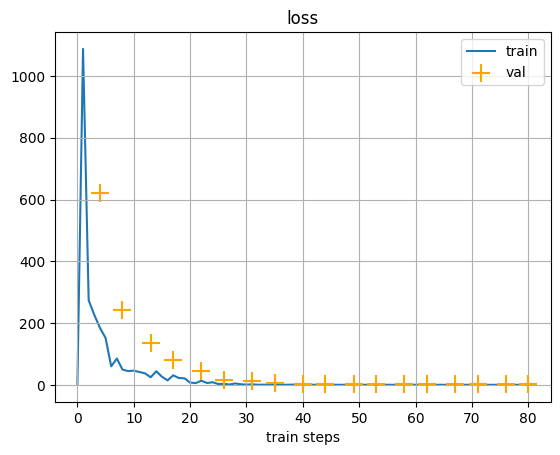

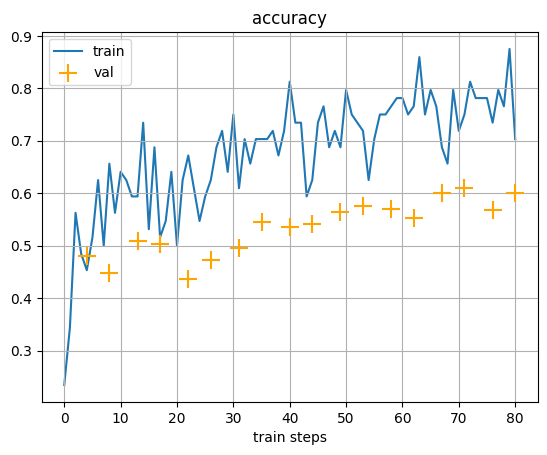

Epoch: 17, val loss: 3.0571137155805315, val accuracy: 0.5995535850524902


In [59]:
fig = train(model, optimizer, criterion, n_epochs=18, scheduler=None, batch_size=64)

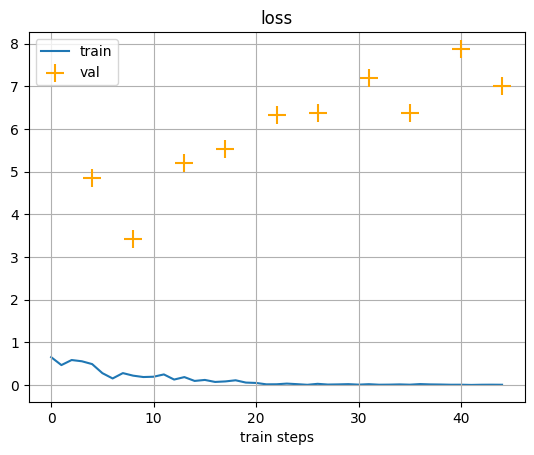

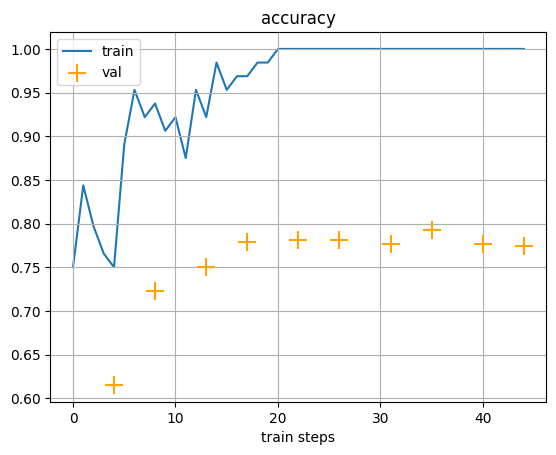

Epoch: 9, val loss: 7.015422996238028, val accuracy: 0.7745535969734192


In [60]:
train_data = datasets.ImageFolder(root=train_dir, transform=test_transform) # transforms to perform on data (images)
train_loader = DataLoader(train_data, batch_size=64, shuffle=True, num_workers=2)
fig = train(model, optimizer, criterion, n_epochs=10, scheduler=None, batch_size=64)

### <center> Optuna </center>

In [82]:
from math import floor  # Импортируем функцию floor для округления вниз (получение целой части числа)

def define_model(trial):
    """
    Функция для динамического построения архитектуры сверточной нейронной сети
    с использованием Optuna для автоматического подбора гиперпараметров.
    
    Args:
        trial: объект Optuna trial, который предлагает значения гиперпараметров
               и отслеживает их в процессе оптимизации
    
    Returns:
        nn.Sequential: скомпонованная последовательная модель PyTorch
    """
    
    # Определяем количество сверточных слоев (от 2 до 5)
    # Optuna будет пробовать разные значения в этом диапазоне
    n_layers = trial.suggest_int("n_layers", 2, 5)
    
    # Список для накопления слоев нейронной сети
    layers = []

    # Начальные параметры:
    in_channels = 1  # Количество входных каналов (1 = изображение в градациях серого)
                     # Если бы было RGB, то 3
    out_channels = 1 # Временная переменная для выходных каналов (будет переопределена)
    
    # Размеры изображения (высота и ширина)
    # img_size должен быть определен глобально ранее в коде (например, 300)
    h, w = img_size, img_size

    # Цикл построения сверточных блоков
    # range(1, n_layers) создает последовательность от 1 до n_layers-1
    # т.е. если n_layers=3, то будет 2 итерации (i=1, i=2)
    for i in range(1, n_layers):
        
        # Предлагаем количество выходных фильтров/каналов для текущего слоя (от 8 до 64)
        # Название параметра уникально для каждого слоя: "n_units_1", "n_units_2" и т.д.
        out_channels = trial.suggest_int("n_units_{}".format(i), 8, 64)
        
        # Предлагаем размер ядра свертки (от 2x2 до 5x5)
        # Например: "kernel_1", "kernel_2" и т.д.
        kernel_size = trial.suggest_int("kernel_{}".format(i), 2, 5)
        
        # Добавляем сверточный слой
        # in_channels - количество входных каналов (с предыдущего слоя)
        # out_channels - количество выходных фильтров/карт признаков
        # kernel_size - размер квадратного ядра свертки
        layers.append(nn.Conv2d(in_channels=in_channels, 
                                out_channels=out_channels, 
                                kernel_size=kernel_size))
        
        # Добавляем слой батч-нормализации для стабилизации обучения
        # Нормализует активации по батчу, ускоряет сходимость
        layers.append(nn.BatchNorm2d(out_channels))
        
        # Добавляем функцию активации ReLU (Rectified Linear Unit)
        # ReLU(x) = max(0, x) - вносит нелинейность в модель
        layers.append(nn.ReLU())
        
        # Добавляем слой MaxPooling с окном 2x2
        # Уменьшает пространственные размеры (высоту и ширину) в 2 раза
        # Берет максимальное значение из каждого окна 2x2
        layers.append(nn.MaxPool2d(kernel_size=2))

        # ВЫЧИСЛЕНИЕ РАЗМЕРОВ ПОСЛЕ СВЕРТКИ
        # Формула для вычисления выходного размера после Conv2d:
        # output_size = floor(((input_size - kernel_size + 2*padding) / stride) + 1)
        # 
        # В данном случае: padding=0 (по умолчанию), stride=1 (по умолчанию)
        # Поэтому: output_size = floor(((input_size - kernel_size + 1 - 1) / 1) + 1)
        # Упрощается до: output_size = input_size - kernel_size + 1
        h = floor(((h - kernel_size + 1 - 1) / 1) + 1)  # Новая высота после свертки
        w = floor(((w - kernel_size + 1 - 1) / 1) + 1)  # Новая ширина после свертки

        # ВЫЧИСЛЕНИЕ РАЗМЕРОВ ПОСЛЕ MAXPOOLING
        # MaxPool2d с kernel_size=2, stride=2 (по умолчанию stride=kernel_size)
        # Формула: output_size = floor(((input_size - kernel_size) / stride) + 1)
        # В данном случае: output_size = floor(((input_size - 2) / 2) + 1)
        h = floor(((h - 2 + 1 - 1) / 2) + 1)  # Новая высота после пулинга
        w = floor(((w - 2 + 1 - 1) / 2) + 1)  # Новая ширина после пулинга
        
        # Обновляем количество входных каналов для следующего слоя
        # Выходные каналы текущего слоя становятся входными для следующего
        in_channels = out_channels

    # ПОЛНОСВЯЗНАЯ ЧАСТЬ СЕТИ
    
    # Преобразуем многомерный тензор (batch, channels, height, width) 
    # в двумерный (batch, features) для полносвязного слоя
    layers.append(nn.Flatten())
    
    # Полносвязный (Linear) слой
    # Входной размер: h * w * out_channels - общее количество признаков после свертки
    # Выходной размер: 4 - количество классов (4 типа опухолей)
    layers.append(nn.Linear(h * w * out_channels, 4))
    
    # Подбираем коэффициент Dropout (вероятность "выключения" нейронов)
    # Используется для регуляризации и предотвращения переобучения
    # Значение от 0.2 до 0.5 (20% до 50% нейронов случайно отключаются)
    p = trial.suggest_uniform("dropout", 0.2, 0.5)
    layers.append(nn.Dropout(p))
    
    # Собираем все слои в последовательную модель
    # *layers распаковывает список слоев в отдельные аргументы
    return nn.Sequential(*layers)


In [86]:
# Установка библиотеки Optuna (закомментировано, т.к. уже установлена)
# %pip install optuna -q

from torch import optim  # Модуль оптимизаторов PyTorch (Adam, SGD и др.)
import optuna  # Библиотека для автоматического подбора гиперпараметров
from optuna.trial import TrialState  # Состояния испытаний (завершено, прервано и т.д.)

# Количество эпох обучения для каждого испытания
# Относительно небольшое число, чтобы быстрее перебирать варианты
EPOCHS = 5

def objective(trial):
    """
    Целевая функция для оптимизации с помощью Optuna.
    Optuna будет вызывать эту функцию многократно с разными гиперпараметрами,
    стремясь максимизировать (или минимизировать) возвращаемое значение.
    
    Args:
        trial: объект Optuna trial для предложения гиперпараметров
        
    Returns:
        float: точность (accuracy) на валидационной выборке - метрика для оптимизации
    """
    
    # Создаем модель с архитектурой, предложенной trial (из функции define_model)
    # и переносим её на устройство (GPU или CPU)
    model = define_model(trial).to(device)
    
    # ПОДБОР ГИПЕРПАРАМЕТРОВ ОПТИМИЗАТОРА
    
    # Предлагаем выбрать один из оптимизаторов: Adam или AdamW
    # Adam - адаптивный оптимизатор с momentum
    # AdamW - Adam с исправленной weight decay регуляризацией
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "AdamW"])
    
    # Подбираем learning rate (скорость обучения) в логарифмическом масштабе
    # log=True означает, что значения будут равномерно распределены в log-пространстве
    # Диапазон: от 0.00001 до 0.1 (очень важный гиперпараметр!)
    lr = trial.suggest_float("lr", 1e-5, 1e-1, log=True)
    
    # Динамически получаем класс оптимизатора по имени из модуля optim
    # getattr(optim, "Adam") вернет класс torch.optim.Adam
    # model.parameters() - передаем параметры модели для оптимизации
    optimizer = getattr(optim, optimizer_name)(model.parameters(), lr=lr)
    
    # Функция потерь для многоклассовой классификации
    # Объединяет LogSoftmax и NLLLoss в один эффективный слой
    # LogSoftmax - применяет логарифм к вероятностям классов
    criterion = nn.CrossEntropyLoss()

    # Списки для логирования метрик в процессе обучения
    train_loss_log, train_acc_log = [], []  # Потери и точность на обучающей выборке
    val_loss_log, val_acc_log = [], []      # Потери и точность на валидационной выборке
    
    # ЦИКЛ ОБУЧЕНИЯ ПО ЭПОХАМ
    for epoch in range(EPOCHS):

        # Тензоры для накопления потерь и правильных предсказаний за эпоху
        train_epoch_loss = torch.empty(0)      # Пустой тензор для потерь
        train_epoch_true_hits = torch.empty(0) # Пустой тензор для правильных ответов
        
        # РЕЖИМ ОБУЧЕНИЯ
        # Включает dropout, batch normalization работает в режиме обучения
        model.train()

        # Проход по батчам обучающей выборки
        for i, (imgs, labels) in enumerate(train_loader):
            # Переносим данные на устройство (GPU/CPU)
            imgs, labels = imgs.to(device), labels.to(device)
            
            # Прямой проход: получаем предсказания модели
            y_pred = model(imgs)
            
            # Вычисляем функцию потерь (насколько предсказания отличаются от истинных меток)
            loss = criterion(y_pred, labels)
            
            # Обратное распространение: вычисляем градиенты
            loss.backward()
            
            # Обновляем веса модели на основе градиентов
            optimizer.step()
            
            # Обнуляем градиенты для следующей итерации
            # (иначе они будут накапливаться)
            optimizer.zero_grad()
            
            # Сохраняем потери текущего батча (нормализованные на размер батча)
            # loss.cpu().unsqueeze(0) - переносим на CPU и добавляем размерность
            train_epoch_loss = torch.cat(
                (train_epoch_loss, loss.cpu().unsqueeze(0) / labels.cpu().size(0))
            )
            train_loss_log.append(loss.cpu().data / labels.cpu().size(0))

            # Получаем предсказанные классы (индекс максимального значения по оси классов)
            # argmax по dim=-1 возвращает индекс класса с наибольшей вероятностью
            pred_classes = torch.argmax(y_pred.cpu(), dim=-1)
            
            # Подсчитываем количество правильных предсказаний в текущем батче
            # (pred_classes == labels.cpu()) создает булеву маску
            # .sum() подсчитывает количество True (правильных ответов)
            train_epoch_true_hits = torch.cat(
                (
                    train_epoch_true_hits,
                    (pred_classes == labels.cpu()).sum().unsqueeze(0),
                )
            )
            
            # Сохраняем точность текущего батча (доля правильных ответов)
            train_acc_log.append(
                (pred_classes == labels.cpu()).sum() / labels.cpu().shape[0]
            )

        # ВАЛИДАЦИЯ
        
        val_epoch_loss = torch.empty(0)       # Потери на валидации
        val_epoch_true_hits = torch.empty(0)  # Правильные ответы на валидации
        
        # РЕЖИМ ОЦЕНКИ
        # Отключает dropout, batch normalization использует накопленную статистику
        model.eval()
        
        # torch.no_grad() отключает вычисление градиентов (экономит память и ускоряет)
        with torch.no_grad():
            # Проход по валидационной выборке
            for i, (imgs, labels) in enumerate(test_loader):
                imgs, labels = imgs.to(device), labels.to(device)

                # Прямой проход (без обратного распространения)
                y_pred = model(imgs)
                
                # Вычисляем потери
                loss = criterion(y_pred, labels)
                val_epoch_loss = torch.cat(
                    (val_epoch_loss, loss.cpu().unsqueeze(0) / labels.cpu().size(0))
                )

                # Получаем предсказанные классы
                pred_classes = torch.argmax(y_pred.cpu(), dim=-1)
                
                # Подсчитываем правильные ответы
                val_epoch_true_hits = torch.cat(
                    (
                        val_epoch_true_hits,
                        (pred_classes == labels.cpu()).sum().unsqueeze(0),
                    )
                )

        # Логируем средние значения за эпоху для валидации
        val_loss_log.append(val_epoch_loss.mean())
        
        # Вычисляем общую точность на валидации:
        # val_epoch_true_hits.sum() - общее число правильных ответов
        # val_epoch_true_hits.size(0) - количество батчей
        # test_loader.batch_size - размер батча
        # Итого: доля правильных ответов от всех примеров
        val_acc_log.append(
            val_epoch_true_hits.sum()
            / val_epoch_true_hits.size(0)
            / test_loader.batch_size
        )
        
        # Сохраняем точность как Python float (для Optuna)
        accuracy = (val_epoch_true_hits.sum()
                / val_epoch_true_hits.size(0)
                / test_loader.batch_size).item()

        # МЕХАНИЗМ PRUNING (ОТСЕЧЕНИЯ) OPTUNA
        
        # Сообщаем Optuna промежуточное значение метрики после текущей эпохи
        # Это позволяет Optuna принять решение о продолжении или прекращении испытания
        trial.report(accuracy, epoch)

        # Проверяем, следует ли прервать испытание (pruning)
        # Optuna может прервать неперспективные испытания досрочно,
        # чтобы не тратить время на обучение заведомо плохих моделей
        # Например, если после 2 эпох точность намного ниже, чем у других испытаний
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    # Возвращаем финальную точность на валидации
    # Optuna будет стремиться максимизировать это значение
    return accuracy


In [87]:
if __name__ == "__main__":
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=75, timeout=12000)

    pruned_trials = study.get_trials(deepcopy=False, states=[TrialState.PRUNED])
    complete_trials = study.get_trials(deepcopy=False, states=[TrialState.COMPLETE])

    print("Study statistics: ")
    print("  Number of finished trials: ", len(study.trials))
    print("  Number of pruned trials: ", len(pruned_trials))
    print("  Number of complete trials: ", len(complete_trials))

    print("Best trial:")
    trial = study.best_trial

    print("  Value: ", trial.value)

    print("  Params: ")
    for key, value in trial.params.items():
        print("    {}: {}".format(key, value))

[I 2024-01-14 21:50:48,829] A new study created in memory with name: no-name-3d77298e-9cbb-42eb-b245-6b923a40c9d2
<ipython-input-82-b705bf2e4a0a>:26: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  p = trial.suggest_uniform("dropout", 0.2, 0.5)
[I 2024-01-14 21:52:25,762] Trial 0 finished with value: 0.5803571343421936 and parameters: {'n_layers': 4, 'n_units_1': 30, 'kernel_1': 3, 'n_units_2': 31, 'kernel_2': 4, 'n_units_3': 38, 'kernel_3': 4, 'dropout': 0.36066263814341926, 'optimizer': 'Adam', 'lr': 0.0003085083423852963}. Best is trial 0 with value: 0.5803571343421936.
[I 2024-01-14 21:54:00,170] Trial 1 finished with value: 0.375 and parameters: {'n_layers': 4, 'n_units_1': 32, 'kernel_1': 2, 'n_units_2': 17, 'kernel_2': 3, 'n_units_3': 17, 'kernel_3': 3, 'dropout': 0.37181458711486726, 'optimizer': 'AdamW', 'lr': 0.038260594281817606}. Best 

Study statistics: 
  Number of finished trials:  75
  Number of pruned trials:  59
  Number of complete trials:  16
Best trial:
  Value:  0.6428571343421936
  Params: 
    n_layers: 2
    n_units_1: 56
    kernel_1: 4
    dropout: 0.42618967681946335
    optimizer: AdamW
    lr: 1.1986748428270307e-05


### <center> Transfer learning </center>

In [80]:
from torchvision import models  # Импорт модуля с предобученными моделями

# ЗАГРУЗКА ПРЕДОБУЧЕННОЙ МОДЕЛИ (TRANSFER LEARNING)

# Загружаем ResNet152 - глубокую сверточную сеть из 152 слоев
# pretrained=True - загружаем веса, обученные на ImageNet (1.2 млн изображений, 1000 классов)
# Эта модель уже "знает" базовые признаки: края, текстуры, формы, объекты
# .to(device) - переносим модель на GPU/CPU
model = models.resnet152(pretrained=True).to(device)

# ЗАМОРОЗКА ВЕСОВ ПРЕДОБУЧЕННОЙ МОДЕЛИ

# Проходим по всем параметрам (весам и смещениям) модели
for param in model.parameters():
    # requires_grad=False означает, что градиенты не будут вычисляться
    # Это "замораживает" веса - они не будут обновляться во время обучения
    # Зачем? Предобученные слои уже извлекают хорошие признаки, нам нужно
    # обучить только финальный классификатор под нашу задачу
    param.requires_grad = False

# УСТАНОВКА SEED ДЛЯ ВОСПРОИЗВОДИМОСТИ РЕЗУЛЬТАТОВ

# Фиксируем генератор случайных чисел для CPU
torch.manual_seed(42)
# Фиксируем генератор случайных чисел для CUDA (GPU)
torch.cuda.manual_seed(42)
# Теперь инициализация весов будет одинаковой при каждом запуске

In [82]:
# ЗАМЕНА ФИНАЛЬНОГО КЛАССИФИКАТОРА

# ResNet152 изначально имеет слой model.fc (fully connected) для 1000 классов ImageNet
# Мы заменяем его на свой классификатор для 4 классов (типы опухолей)

model.fc = torch.nn.Sequential(
    # Первый полносвязный слой:
    # in_features=2048 - размерность выхода последнего сверточного слоя ResNet152
    # out_features=512 - промежуточное представление (bottleneck layer)
    torch.nn.Linear(in_features=2048, out_features=512, bias=True),
    
    # Dropout для регуляризации (предотвращение переобучения)
    # p=0.3 - вероятность "выключения" нейрона (30%)
    # inplace=True - экономит память, модифицируя тензор на месте
    torch.nn.Dropout(p=0.3, inplace=True),
    
    # ReLU - функция активации для нелинейности
    nn.ReLU(),
    
    # Выходной слой:
    # in_features=512 - из предыдущего слоя
    # out_features=4 - количество классов в нашей задаче
    torch.nn.Linear(in_features=512, out_features=4, bias=True)
).to(device)  # Переносим новый классификатор на устройство

# НАСТРОЙКА ОБУЧЕНИЯ

# Функция потерь для многоклассовой классификации
criterion = nn.CrossEntropyLoss()

# Оптимизатор Adam
# model.parameters() - теперь включает только параметры нового классификатора (model.fc)
# потому что остальные параметры имеют requires_grad=False
# lr=1e-2 (0.01) - относительно высокий learning rate, т.к. обучаем только последний слой
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

In [85]:
# ТРАНСФОРМАЦИИ ДЛЯ АУГМЕНТАЦИИ ДАННЫХ (DATA AUGMENTATION)

data_transform = transforms.Compose([
    # Изменение размера до 224x224 - стандартный вход для ResNet
    # ImageNet модели обучались на таких размерах
    transforms.Resize((224, 224)),
    
    # Преобразование PIL Image в тензор PyTorch
    transforms.ToTensor(),
    
    # Нормализация с параметрами ImageNet
    # mean и std - средние значения и стандартные отклонения по RGB каналам
    # Это стандартные значения для моделей, обученных на ImageNet
    # Критично использовать те же значения, что и при предобучении resnet!
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    
    # АУГМЕНТАЦИИ ДЛЯ УВЕЛИЧЕНИЯ РАЗНООБРАЗИЯ ДАННЫХ:
    
    # Случайное вертикальное отражение с вероятностью 30%
    # Помогает модели стать инвариантной к ориентации изображения
    transforms.RandomVerticalFlip(p=0.3),
    
    # Случайное горизонтальное отражение с вероятностью 30%
    transforms.RandomHorizontalFlip(p=0.3),
    
    # Случайные аффинные преобразования (повороты до ±20 градусов, сдвиги, масштабирование)
    # Делает модель устойчивой к небольшим поворотам и искажениям
    transforms.RandomAffine(20)
])

# ТРАНСФОРМАЦИИ ДЛЯ ТЕСТОВЫХ ДАННЫХ (БЕЗ АУГМЕНТАЦИИ!)

test_transform = transforms.Compose([
    # Только базовые преобразования, без случайных искажений
    # На тесте мы хотим оценить "чистую" производительность модели
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    # Та же нормализация ImageNet обязательна!
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ЗАГРУЗКА ДАТАСЕТОВ


train_data_aug = datasets.ImageFolder(root=train_dir, transform=train_transform)

# Тестовая выборка - без аугментации
test_data = datasets.ImageFolder(root=test_dir, transform=test_transform)

# СОЗДАНИЕ ЗАГРУЗЧИКОВ ДАННЫХ

train_loader = DataLoader(
    train_data_aug,
    batch_size=32,      # Размер батча - 32 изображения за итерацию
                        # Меньше, чем раньше (64), т.к. ResNet152 требует больше памяти
    shuffle=True,       # Перемешиваем данные на каждой эпохе
    num_workers=2       # Количество параллельных процессов для загрузки данных
                        # Ускоряет загрузку, особенно с аугментацией
)

test_loader = DataLoader(
    test_data,
    batch_size=32,
    shuffle=False,      # Для теста не перемешиваем
    num_workers=2
)

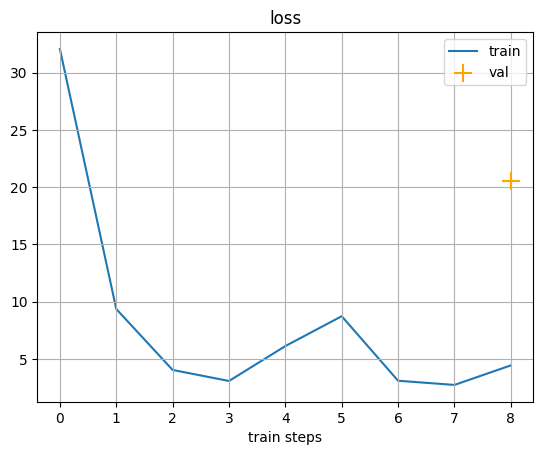

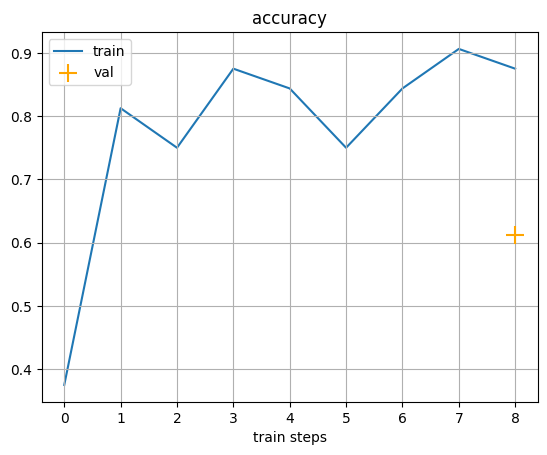

Epoch: 0, val loss: 20.492470243802437, val accuracy: 0.612500011920929


In [87]:
fig = train(model, optimizer, criterion, n_epochs=1, scheduler=None, batch_size=32)

### <center> Knowledge distillation </center>

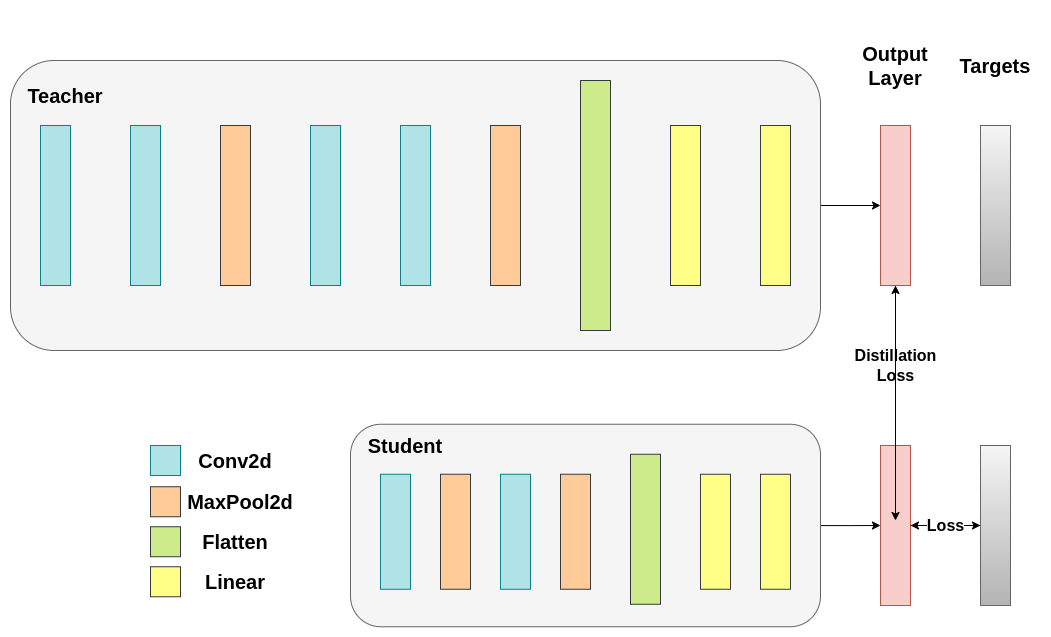